# 01 — Train Emulator: Cosmic Star Formation Rate (CSFR)

Single-epoch emulator (no multi-z data available for CSFR).
Saves model to `../models/CSFR_multivariate_model_z_index0.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *

## Configuration

In [2]:
DirIn = '../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/'

start_sim_idx = 1
num_sims = 39
exp_variance = 0.95

test_indices = [3, 14, 35]
train_indices = [i for i in np.arange(num_sims) if i not in test_indices]

## Load parameters

params32 shape: (39, 7)


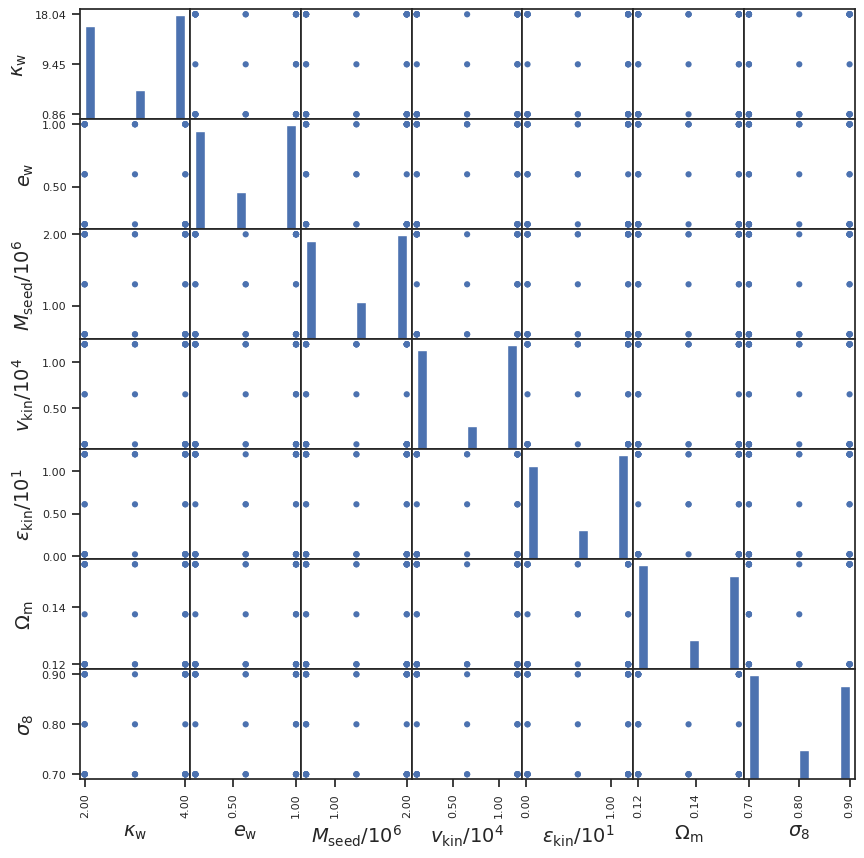

In [3]:
fileIn = '../data/FinalDesign.txt'
params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
params32 = params_all[start_sim_idx - 1 : start_sim_idx - 1 + num_sims]

params32[:, 2] = params32[:, 2] / seed_mass_scale
params32[:, 3] = params32[:, 3] / vkin_scale
params32[:, 4] = params32[:, 4] / eps_scale

print('params32 shape:', params32.shape)

df_train = pd.DataFrame(params32, columns=PARAM_NAME)
plot_scatter_matrix(df_train, ['b'] * params32.shape[0]);
plt.savefig('../plots/exp_design_csfr.png', bbox_inches='tight')

## Load and visualize CSFR

In [4]:
scale_factor, csfr_arr = read_csfr(DirIn, num_sims, start_sim_idx=start_sim_idx)
print('scale_factor shape:', scale_factor.shape)
print('csfr_arr shape:', csfr_arr.shape)

color_by_index = 4
plt_strings = plot_strings('CSFR')
mlim1, mlim2 = mass_conds('CSFR')

f, a = plt.subplots(1, 1, figsize=(6, 3))
f = plot_lines_with_param_color(params32[:, color_by_index],
                                scale_factor, csfr_arr,
                                *plt_strings, PARAM_NAME[color_by_index],
                                mlim1, mlim2, a);
plt.title('Cosmic Star Formation Rate')
plt.savefig('../plots/CSFR_design.png', bbox_inches='tight')

FileNotFoundError: ../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/RUN001/extract/CSFR.txt not found.

## Data prep, PCA, and GP training

In [ ]:
csfr_arr_extra = fill_nan_with_interpolation(csfr_arr, 'linear')

mass_cond = np.where((scale_factor >= mlim1) & (scale_factor <= mlim2))
y_vals = csfr_arr_extra[:, mass_cond[0]]
y_ind = scale_factor[mass_cond]
print('y_vals shape:', y_vals.shape, '  y_ind shape:', y_ind.shape)

# Train-test split
p_all_train = params32[train_indices]
y_vals_train = y_vals[train_indices]

# Fit
z_index = 0
model_filename = '../models/CSFR_multivariate_model_z_index' + str(z_index)

sepia_data = sepia_data_format(p_all_train, y_vals_train, y_ind)
sepia_model = do_pca(sepia_data, exp_variance=exp_variance)
sepia_model = do_gp_train(sepia_model, model_filename)
sepia_model = gp_load(sepia_model, model_filename)
plot_train_diagnostics(sepia_model)

## PCA basis

In [ ]:
from sepia import SepiaPlot
SepiaPlot.plot_K_basis(sepia_data, max_plots=1);

## Validation

In [ ]:
input_params = params32[test_indices]
target_vals = y_vals[test_indices]

pred_mean, pred_quant = emulate(sepia_model, input_params)
plt_strings = plot_strings('CSFR')
mlim1, mlim2 = mass_conds('CSFR')

validation_plot(y_ind, target_vals, pred_mean, pred_quant,
                *plt_strings, mlim1, mlim2, 'linear', 'linear');
plt.savefig('../plots/CSFR_valid.png', bbox_inches='tight')

## Sensitivity

In [ ]:
f = sensitivity_plot(y_ind, params32, sepia_model, emulate, PARAM_NAME,
                     *plt_strings, mlim1, mlim2, 'linear', 'linear')
plt.savefig('../plots/CSFR_sensi.png', bbox_inches='tight')